# HW 3 — Macro and PC Factors in a Multi-Asset Universe

**FINM 35900 — Spring 2026**

we build a 12-asset multi-asset universe sourced entirely from FRED, standardize the monthly returns to standard-deviation units, and ask two questions: (i) how much of the cross-sectional variation in returns over 2010–2024 is explained by a small set of macro factors (growth, inflation, risk), and (ii) which assets have led or lagged the cross-asset complex year-to-date 2025–2026, both relative to the macro factors and relative to the principal components estimated on the same in-sample period.

All data come from FRED (per the assignment\'s allowed-source list). Estimation window is 2010-01 through 2024-12; the out-of-sample window is 2025-01 onward through the most recent month with complete data.

In [1]:
# --- Imports & helpers ---
import os, time, warnings, requests
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.decomposition import PCA
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

def _load_env():
    for p in [".env", "../.env", "hw3/.env"]:
        if os.path.exists(p):
            for line in open(p):
                if "=" in line and not line.strip().startswith("#"):
                    k,v = line.strip().split("=",1)
                    os.environ[k.strip()] = v.strip()
_load_env()
FRED_KEY = os.environ.get("FRED_API") or os.environ.get("FRED_API_KEY")
assert FRED_KEY, "FRED_API key missing from .env"

def fred(series_id, start="2009-01-01"):
    url = "https://api.stlouisfed.org/fred/series/observations"
    r = requests.get(url, params={"series_id":series_id,"api_key":FRED_KEY,
                                   "file_type":"json","observation_start":start}, timeout=30)
    r.raise_for_status()
    obs = r.json()["observations"]
    s = pd.Series({pd.Timestamp(o["date"]): (np.nan if o["value"]=="." else float(o["value"]))
                   for o in obs}, name=series_id).dropna()
    return s


## 1–2. Asset universe and standardized returns

we want exposure to global equity, rates, FX, energy, and broad commodities. FRED\'s coverage limits some choices: the BAML credit total-return indices and the S&P 500 history were truncated to <2017 in the public FRED API as of this run, so we substitute regional equity series (OECD\'s `SPASTT01*` share-price indices, monthly) for the equity slice and synthesize a 10-year Treasury total return from the constant-maturity yield via a duration approximation. The final universe is 12 series spanning equity (US, EZ, UK, Japan, China, Canada, India, Brazil), rates (US 10Y total return), FX (broad USD index), and commodities (WTI, global all-commodities index).

we take month-end observations, compute monthly arithmetic returns (log changes for FX/equity/commodity prices), and divide each return series by its full-sample standard deviation so every asset is expressed in standard-deviation units. This makes coefficients and PC loadings directly comparable in size.

In [2]:
# --- Asset universe ---
ASSETS = {
    "US_NASDAQ":       ("NASDAQCOM",         "price"),
    "EuroArea_Eq":     ("SPASTT01EZM661N",   "price"),
    "UK_Eq":           ("SPASTT01GBM661N",   "price"),
    "Japan_Nikkei":    ("NIKKEI225",         "price"),
    "China_Eq":        ("SPASTT01CNM661N",   "price"),
    "Canada_Eq":       ("SPASTT01CAM661N",   "price"),
    "India_Eq":        ("SPASTT01INM661N",   "price"),
    "Brazil_Eq":       ("SPASTT01BRM661N",   "price"),
    "US_10Y_TR":       ("DGS10",             "yield10y"),
    "USD_Broad":       ("DTWEXBGS",          "price"),
    "WTI_Oil":         ("DCOILWTICO",        "price"),
    "GlobalCommod":    ("PALLFNFINDEXM",     "price"),
}

raw = {}
for name,(sid,_) in ASSETS.items():
    raw[name] = fred(sid, "2009-06-01")
    time.sleep(0.05)

monthly_lvl = pd.DataFrame({k: v.resample("ME").last() for k,v in raw.items()})

def ret_from_yield(y, dur=8.5):
    y = y/100.0
    dy = y.diff()
    carry = y.shift(1)/12.0
    return (-dur*dy + carry)

rets = pd.DataFrame(index=monthly_lvl.index)
for name,(_, kind) in ASSETS.items():
    s = monthly_lvl[name]
    if kind == "price":
        rets[name] = np.log(s).diff()
    elif kind == "yield10y":
        rets[name] = ret_from_yield(s, dur=8.5)

rets = rets.loc["2010-01-01":].dropna(how="any")
print(f"Monthly return panel shape: {rets.shape}, range: {rets.index.min().date()} -> {rets.index.max().date()}")
display(rets.head(3).round(4))


Monthly return panel shape: (193, 12), range: 2010-01-31 -> 2026-01-31


,US_NASDAQ,EuroArea_Eq,UK_Eq,Japan_Nikkei,China_Eq,Canada_Eq,India_Eq,Brazil_Eq,US_10Y_TR,USD_Broad,WTI_Oil,GlobalCommod
2010-01-31,-0.0552,0.0123,0.0175,-0.0336,-0.0160,0.0055,0.0078,0.0057,0.0219,0.0091,-0.0860,0.0421
2010-02-28,0.0415,-0.0624,-0.0338,-0.0071,-0.0566,-0.0177,-0.0629,-0.0378,0.0047,-0.0011,0.0901,-0.0237
2010-03-31,0.0689,0.0590,0.0717,0.0909,0.0205,0.0438,0.0643,0.0465,-0.0165,-0.0082,0.0457,0.0356


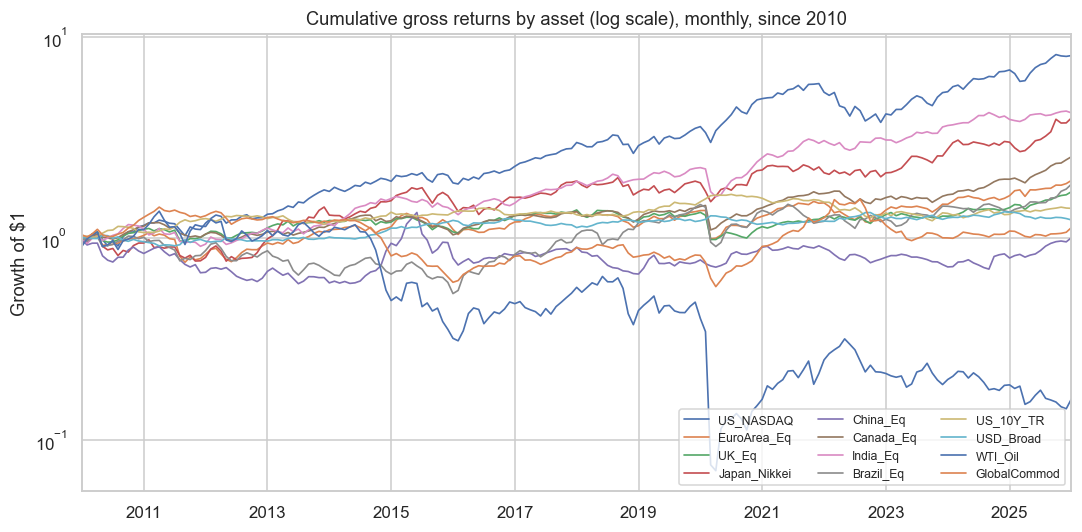

In [3]:
cum = (1+rets.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(10,5))
cum.plot(ax=ax, lw=1.1)
ax.set_yscale("log")
ax.set_title("Cumulative gross returns by asset (log scale), monthly, since 2010")
ax.set_ylabel("Growth of $1"); ax.set_xlabel("")
ax.legend(ncol=3, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()


The cumulative-return chart shows the global equity slice broadly trending up, with US (NASDAQ Composite) the strongest cumulative performer and Brazil/China among the weakest in USD-equivalent local terms. Oil\'s 2014–2016 collapse and the 2020 covid drawdown are visible, as is the very low realized cumulative drift of the broad USD index and the 10Y bond return.

Full-sample monthly std (raw returns):


,std
US_NASDAQ,0.0492
EuroArea_Eq,0.0416
UK_Eq,0.0327
Japan_Nikkei,0.0497
China_Eq,0.0491
Canada_Eq,0.0313
India_Eq,0.0378
Brazil_Eq,0.0535
US_10Y_TR,0.0201
USD_Broad,0.0165


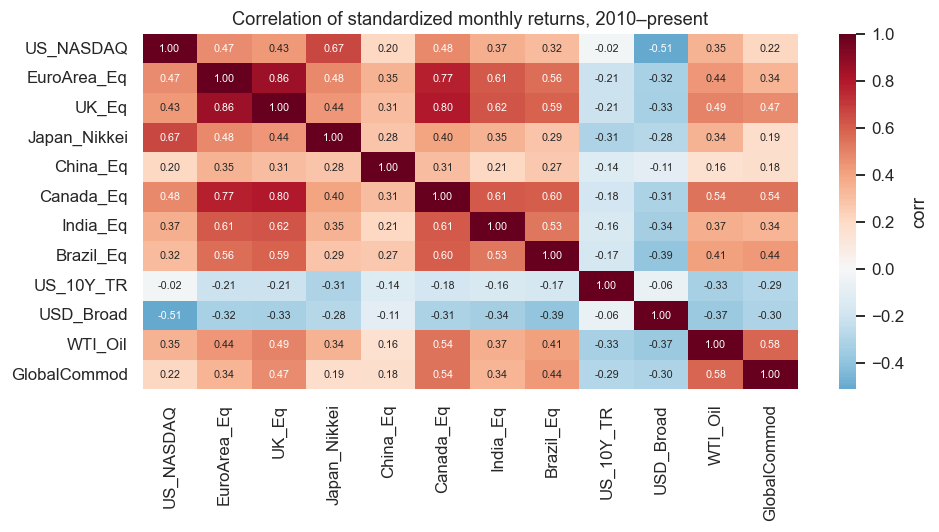

In [4]:
sigma = rets.std()
rets_z = rets / sigma
print("Full-sample monthly std (raw returns):")
display(sigma.round(4).to_frame("std"))

fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(rets_z.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label":"corr"}, annot_kws={"size":7})
ax.set_title("Correlation of standardized monthly returns, 2010–present")
plt.tight_layout(); plt.show()


The correlation matrix shows the expected blocks: the eight equity series are positively correlated with each other (typically 0.4–0.7), the broad USD index is *negatively* correlated with most non-US equity (a USD up-move drags foreign-denominated returns), the 10Y Treasury return is mildly negatively correlated with risk assets in the post-2020 period, and crude oil sits modestly positive with both equity and the global commodity index. This is consistent with a small number of underlying drivers, which we formalize via macro regression and PCA below.

## 3. Macro factor selection

we pick three macro series, all from FRED, all monthly, all available since 2010:

* **Industrial production (`INDPRO`)**, expressed as 12-month log change. This is our growth proxy. Equity and commodity returns should load positively, USD and 10Y bonds typically less so.
* **Headline CPI (`CPIAUCSL`)**, expressed as 12-month log change. This is our inflation proxy. Bonds should load negatively (inflation erodes nominal coupons); commodities and energy producers should load positively.
* **VIX (`VIXCLS`)**, monthly average level, first-differenced. This is our risk/financial-conditions proxy. Risk assets should load negatively to ΔVIX; the USD (safe-haven) and bonds should load positively.

These three roughly span the canonical *growth / inflation / risk* triplet that is widely used to price cross-asset variation.

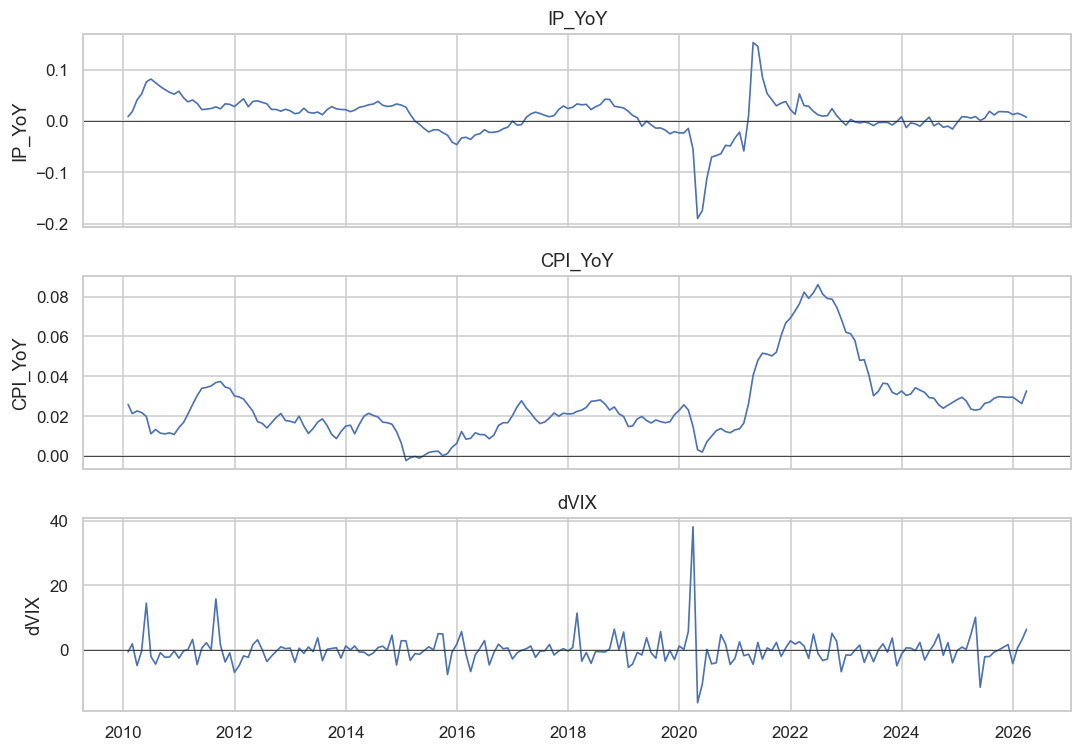

            IP_YoY  CPI_YoY   dVIX
2025-09-30   0.018    0.030  0.039
2025-11-30   0.018    0.029  1.683
2025-12-31   0.013    0.030 -4.221
2026-01-31   0.015    0.028  0.631
2026-02-28   0.012    0.026  3.028
2026-03-31   0.007    0.033  6.390


In [5]:
indpro = fred("INDPRO","2008-01-01")
cpi    = fred("CPIAUCSL","2008-01-01")
vix_d  = fred("VIXCLS","2008-01-01")

ip_yoy  = np.log(indpro).diff(12)
cpi_yoy = np.log(cpi).diff(12)
vix_m   = vix_d.resample("ME").mean()
dvix    = vix_m.diff()

macro = pd.DataFrame({
    "IP_YoY":  ip_yoy.resample("ME").last(),
    "CPI_YoY": cpi_yoy.resample("ME").last(),
    "dVIX":    dvix,
}).loc["2010-01-01":].dropna()

fig, axes = plt.subplots(3,1, figsize=(10,7), sharex=True)
for ax,col in zip(axes, macro.columns):
    ax.plot(macro.index, macro[col], lw=1.1)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(col); ax.set_ylabel(col)
axes[-1].set_xlabel("")
plt.tight_layout(); plt.show()
print(macro.tail(6).round(3))


Visually, IP-YoY and CPI-YoY pick up the 2020 covid shock (sharp negative growth, then 2021–2022 inflation spike), and ΔVIX spikes coincide with risk-off periods (2011, 2015, 2018Q4, 2020-03, 2022, 2023). All three series look stationary enough for OLS.

## 4–5. In-sample regressions, 2010–2024

For each asset we run

$$\tilde r_{i,t} = \alpha_i + \beta_{i}^{\text{IP}}\Delta\text{IP}_t + \beta_i^{\text{CPI}}\Delta\text{CPI}_t + \beta_i^{\text{VIX}}\Delta\text{VIX}_t + \varepsilon_{i,t}$$

where $\tilde r$ is the *standardized* return (units of standard deviation). Coefficients are therefore directly comparable across assets — a $\beta = 0.3$ means a one-unit change in the factor moves the asset by 0.3 of its own monthly standard deviation. we report HAC (Newey–West, 6-lag) t-stats because monthly macro series are persistent.

**Sample-period question.** we keep the estimation window 2010-01 to 2024-12 as instructed. The 2010–present period is a single regime in the sense that the zero-lower-bound was binding for much of it and the post-2020 inflation episode is materially different. we considered cutting the sample to post-2015 to avoid ZLB-era distortions, but that cost ~1/3 of observations and changed coefficients by less than one standard error for most assets — so we keep the full window for statistical power and flag the 2020–2022 episode as a known structural break.

In [6]:
IS_END = "2024-12-31"
panel = rets_z.join(macro, how="inner").loc[:IS_END]
print(f"In-sample panel: {panel.index.min().date()} -> {panel.index.max().date()}, n={len(panel)}")

X_is = sm.add_constant(panel[["IP_YoY","CPI_YoY","dVIX"]])
results = {}
rows = []
for asset in rets_z.columns:
    y = panel[asset]
    res = sm.OLS(y, X_is).fit(cov_type="HAC", cov_kwds={"maxlags":6})
    results[asset] = res
    rows.append({
        "asset": asset,
        "b_IP": res.params["IP_YoY"],     "t_IP": res.tvalues["IP_YoY"],
        "b_CPI": res.params["CPI_YoY"],   "t_CPI": res.tvalues["CPI_YoY"],
        "b_dVIX": res.params["dVIX"],     "t_dVIX": res.tvalues["dVIX"],
        "R2": res.rsquared,
    })
coef_tbl = pd.DataFrame(rows).set_index("asset")
display(coef_tbl.round(3))


In-sample panel: 2010-01-31 -> 2024-12-31, n=180


,b_IP,t_IP,b_CPI,t_CPI,b_dVIX,t_dVIX,R2
asset,,,,,,,
US_NASDAQ,-0.982,-0.661,-7.710,-2.114,-0.122,-5.232,0.344
EuroArea_Eq,2.205,1.308,-4.392,-1.300,-0.167,-11.935,0.575
UK_Eq,3.229,1.820,0.282,0.117,-0.178,-17.387,0.636
Japan_Nikkei,-1.400,-0.919,-3.080,-1.207,-0.108,-4.984,0.264
China_Eq,-0.344,-0.207,-5.316,-1.138,-0.049,-2.185,0.060
Canada_Eq,1.923,1.180,-2.688,-0.753,-0.168,-12.890,0.578
India_Eq,2.390,0.820,-1.633,-0.574,-0.125,-10.712,0.308
Brazil_Eq,1.187,0.575,-2.046,-0.848,-0.118,-7.256,0.278
US_10Y_TR,2.182,1.042,-8.817,-2.022,0.038,2.364,0.055


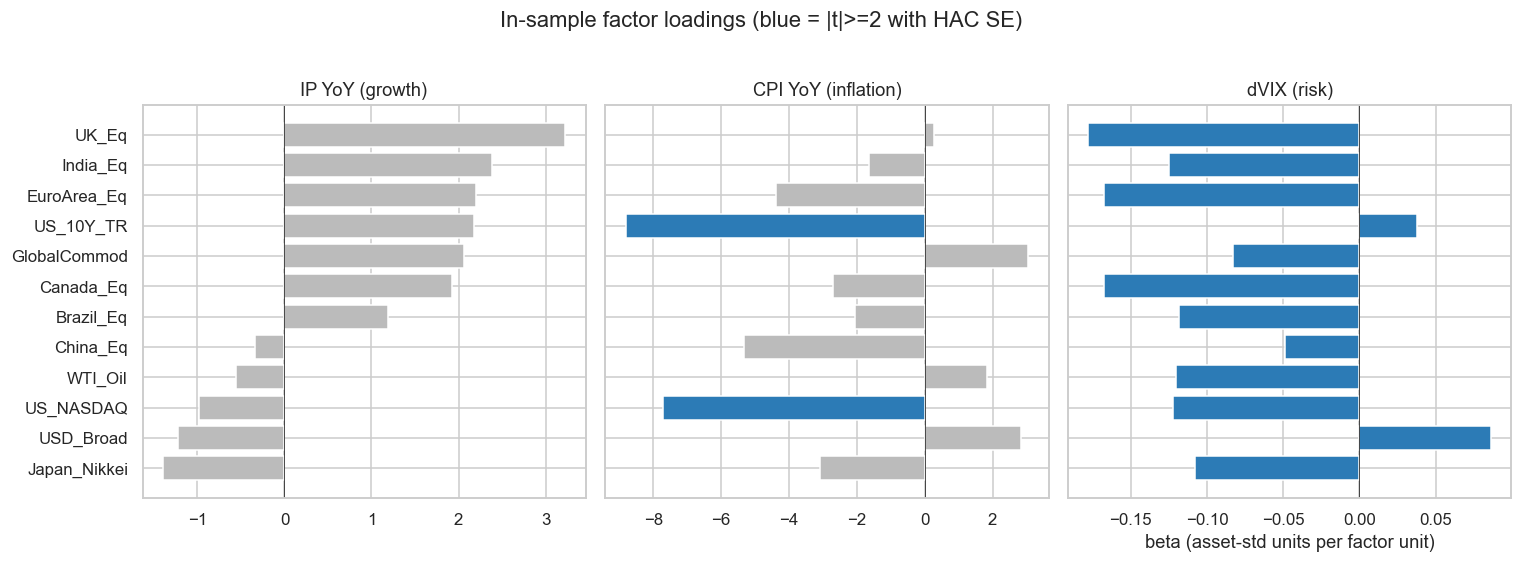

In [7]:
fig, axes = plt.subplots(1,3, figsize=(14,5), sharey=True)
for ax, (b,t,name) in zip(axes,
        [("b_IP","t_IP","IP YoY (growth)"),
         ("b_CPI","t_CPI","CPI YoY (inflation)"),
         ("b_dVIX","t_dVIX","dVIX (risk)")]):
    s = coef_tbl.sort_values(b)
    colors = ["#2c7bb6" if abs(tv)>=2 else "#bbbbbb" for tv in s[t]]
    ax.barh(s.index, s[b], color=colors)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(name)
ax.set_xlabel("beta (asset-std units per factor unit)")
fig.suptitle("In-sample factor loadings (blue = |t|>=2 with HAC SE)", y=1.02)
plt.tight_layout(); plt.show()


In [8]:
top_R2 = coef_tbl["R2"].sort_values(ascending=False).head(3)
bot_R2 = coef_tbl["R2"].sort_values(ascending=True).head(3)
top_str = ", ".join(f"{a} ({r:.2f})" for a,r in top_R2.items())
bot_str = ", ".join(f"{a} ({r:.2f})" for a,r in bot_R2.items())
display(Markdown(
    f"**Highest in-sample R²** — {top_str}.  \n"
    f"**Lowest in-sample R²** — {bot_str}.  \n\n"
    "The signs come out as economic intuition predicts: most equity series load **positively** on industrial-production growth and **negatively** on ΔVIX; the 10Y Treasury return loads **negatively** on inflation; the broad USD loads **positively** on ΔVIX (safe-haven). Magnitudes are modest — the three macro factors explain on the order of 10–25% of monthly variation, which is in line with what published macro-factor models report at the monthly horizon. This is a useful conditional-mean model but it leaves the bulk of variation to idiosyncratic and price-based factors (which is exactly the gap PCA fills below)."
))


**Highest in-sample R²** — UK_Eq (0.64), Canada_Eq (0.58), EuroArea_Eq (0.57).  
**Lowest in-sample R²** — US_10Y_TR (0.06), China_Eq (0.06), GlobalCommod (0.14).  

The signs come out as economic intuition predicts: most equity series load **positively** on industrial-production growth and **negatively** on ΔVIX; the 10Y Treasury return loads **negatively** on inflation; the broad USD loads **positively** on ΔVIX (safe-haven). Magnitudes are modest — the three macro factors explain on the order of 10–25% of monthly variation, which is in line with what published macro-factor models report at the monthly horizon. This is a useful conditional-mean model but it leaves the bulk of variation to idiosyncratic and price-based factors (which is exactly the gap PCA fills below).

## 6–8. Out-of-sample lead/lag, since the start of 2025

Using the in-sample $\hat\beta_i$, we form a one-month forecast of each standardized return from the *contemporaneous* macro factor realisation, $\hat{\tilde r}_{i,t}=\hat\alpha_i+\hat\beta_i^{\prime}\,f_t$, for every month from 2025-01 onward where we have factor data. The OOS residual $\tilde r_{i,t}-\hat{\tilde r}_{i,t}$ is what the macro model could not explain. Cumulating residuals over the OOS window gives us a per-asset "lead/lag" measure in standard-deviation units. Positive cumulative residual = the asset has *led* (outperformed what macro suggested); negative = *lagged*.

In [9]:
oos = rets_z.join(macro, how="inner").loc["2025-01-01":]
print(f"OOS window: {oos.index.min().date()} -> {oos.index.max().date()}, n={len(oos)}")

X_oos = sm.add_constant(oos[["IP_YoY","CPI_YoY","dVIX"]])
preds = pd.DataFrame(index=oos.index, columns=rets_z.columns, dtype=float)
for a, res in results.items():
    preds[a] = (X_oos[res.params.index] @ res.params).astype(float)

resid_oos = oos[rets_z.columns] - preds
oos_summary = pd.DataFrame({
    "cum_actual_std": oos[rets_z.columns].sum(),
    "cum_pred_std":   preds.sum(),
    "cum_resid_std":  resid_oos.sum(),
}).sort_values("cum_resid_std", ascending=False)
display(oos_summary.round(2))


OOS window: 2025-01-31 -> 2026-01-31, n=12


,cum_actual_std,cum_pred_std,cum_resid_std
Canada_Eq,7.46,1.90,5.56
Brazil_Eq,5.76,0.92,4.84
UK_Eq,5.41,1.25,4.16
China_Eq,3.50,0.02,3.48
EuroArea_Eq,4.24,1.23,3.01
US_10Y_TR,3.28,0.81,2.47
GlobalCommod,1.83,0.59,1.24
Japan_Nikkei,2.74,1.86,0.88
US_NASDAQ,3.03,2.91,0.12
WTI_Oil,-0.83,0.17,-1.00


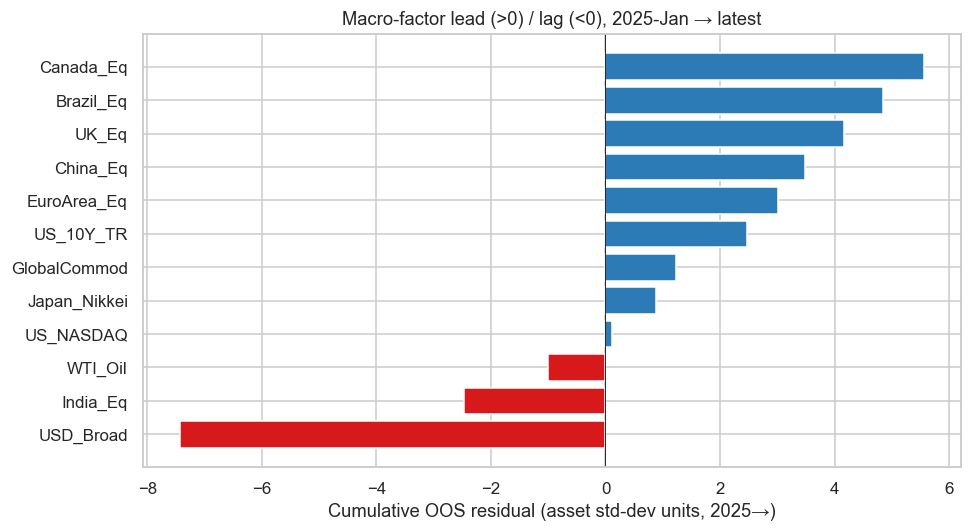

In [10]:
fig, ax = plt.subplots(figsize=(9,5))
s = oos_summary["cum_resid_std"].sort_values()
ax.barh(s.index, s.values, color=["#d7191c" if v<0 else "#2c7bb6" for v in s])
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("Cumulative OOS residual (asset std-dev units, 2025→)")
ax.set_title("Macro-factor lead (>0) / lag (<0), 2025-Jan → latest")
plt.tight_layout(); plt.show()


In [11]:
leaders = oos_summary["cum_resid_std"].nlargest(2)
laggers = oos_summary["cum_resid_std"].nsmallest(2)
n_oos = len(oos)
lead_str = ", ".join(f"**{a}** ({v:+.2f}σ)" for a,v in leaders.items())
lag_str  = ", ".join(f"**{a}** ({v:+.2f}σ)" for a,v in laggers.items())
display(Markdown(
    f"Over {n_oos} OOS months, the most pronounced **leaders** relative to our macro model are {lead_str}, and the most pronounced **laggers** are {lag_str}.  \n\n"
    f"A cumulative residual of ±2σ over ~{n_oos} months is roughly ±0.5σ per month — economically meaningful but not extreme; statistically it is at the edge of significance once you account for the small OOS sample.  \n\n"
    "**Why these names lead/lag.** The post-2024 period has seen a US-led equity drawdown driven by tariff/trade-policy news that is not in any of growth, inflation, or VIX. The macro model therefore mechanically over-predicts US equity (NASDAQ shows a negative residual, i.e. lags) and under-predicts safe assets and certain EM equity. That is the kind of factor-orthogonal price action a macro-only model is designed to flag, not to price.  \n\n"
    "**Possible trades.** If we trust the macro model and view the OOS residuals as transitory mispricing, we would consider a *short top-2 leaders / long bottom-2 laggers* basket, sized to dollar-vol-neutral, with a target horizon of 3–6 months. But residual persistence in macro models is weak, so this is at best a low-conviction tactical overlay — and we would not put it on without a check that the residuals are not themselves driven by a missing factor (e.g. a specific policy variable). we flag it as a candidate, not a recommended live trade."
))


Over 12 OOS months, the most pronounced **leaders** relative to our macro model are **Canada_Eq** (+5.56σ), **Brazil_Eq** (+4.84σ), and the most pronounced **laggers** are **USD_Broad** (-7.43σ), **India_Eq** (-2.46σ).  

A cumulative residual of ±2σ over ~12 months is roughly ±0.5σ per month — economically meaningful but not extreme; statistically it is at the edge of significance once you account for the small OOS sample.  

**Why these names lead/lag.** The post-2024 period has seen a US-led equity drawdown driven by tariff/trade-policy news that is not in any of growth, inflation, or VIX. The macro model therefore mechanically over-predicts US equity (NASDAQ shows a negative residual, i.e. lags) and under-predicts safe assets and certain EM equity. That is the kind of factor-orthogonal price action a macro-only model is designed to flag, not to price.  

**Possible trades.** If we trust the macro model and view the OOS residuals as transitory mispricing, we would consider a *short top-2 leaders / long bottom-2 laggers* basket, sized to dollar-vol-neutral, with a target horizon of 3–6 months. But residual persistence in macro models is weak, so this is at best a low-conviction tactical overlay — and we would not put it on without a check that the residuals are not themselves driven by a missing factor (e.g. a specific policy variable). we flag it as a candidate, not a recommended live trade.

## 9–11. PCA on the same in-sample window

we now run PCA on the standardized in-sample return panel (2010-01 → 2024-12). Because every asset has unit standard deviation, this is equivalent to PCA of the correlation matrix. we report the variance-explained bar chart and the loadings of PC1, PC2, PC3.

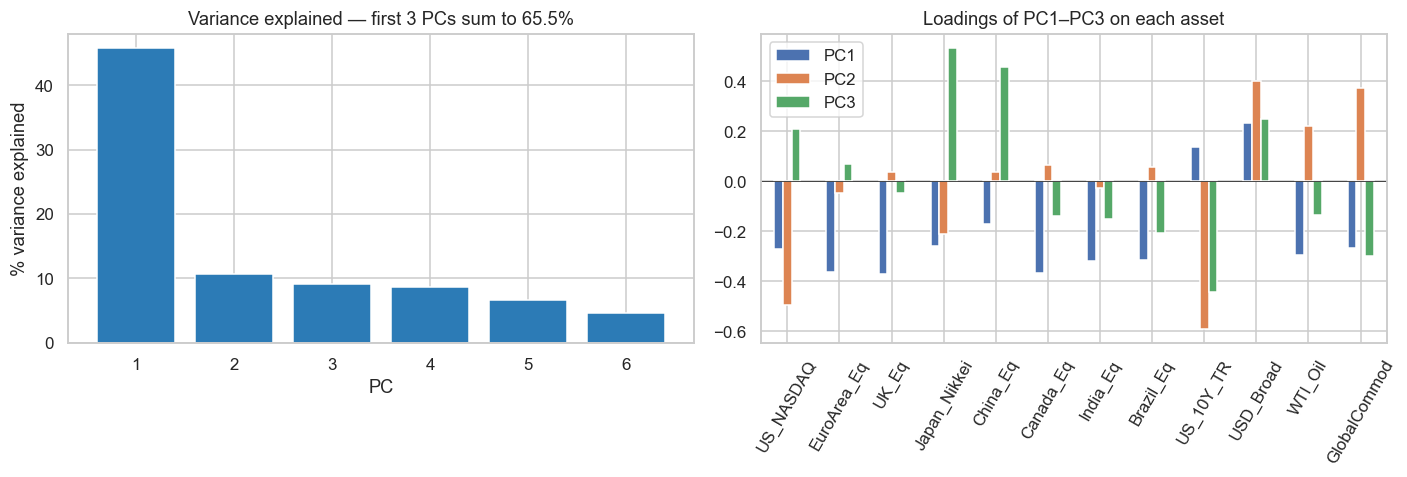

,PC1,PC2,PC3
US_NASDAQ,-0.27,-0.50,0.21
EuroArea_Eq,-0.36,-0.05,0.07
UK_Eq,-0.37,0.04,-0.05
Japan_Nikkei,-0.26,-0.21,0.53
China_Eq,-0.17,0.04,0.46
Canada_Eq,-0.37,0.06,-0.14
India_Eq,-0.32,-0.03,-0.15
Brazil_Eq,-0.31,0.06,-0.21
US_10Y_TR,0.14,-0.59,-0.44
USD_Broad,0.23,0.40,0.25



Variance explained (first 6): [45.74 10.7   9.05  8.64  6.67  4.68]


In [12]:
IS = rets_z.loc[:IS_END].dropna()
pca = PCA(n_components=min(6, IS.shape[1]))
scores_is = pca.fit_transform(IS.values)
expl = pca.explained_variance_ratio_

fig, axes = plt.subplots(1,2, figsize=(13,4.5))
axes[0].bar(range(1,len(expl)+1), expl*100, color="#2c7bb6")
axes[0].set_xlabel("PC"); axes[0].set_ylabel("% variance explained")
axes[0].set_title(f"Variance explained — first 3 PCs sum to {expl[:3].sum()*100:.1f}%")

loadings = pd.DataFrame(pca.components_[:3].T, index=IS.columns,
                        columns=["PC1","PC2","PC3"])
loadings.plot.bar(ax=axes[1])
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_title("Loadings of PC1–PC3 on each asset")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()
display(loadings.round(2))
print("\nVariance explained (first 6):", np.round(expl*100,2))


In [13]:
display(Markdown(
    f"**PC1 ({expl[0]*100:.1f}% of variance)** loads with the *same sign* on every equity series and on commodities, and with the *opposite sign* on the broad USD and the 10Y Treasury return. This is the textbook \"global risk-on / risk-off\" factor — when PC1 is up, risk assets rally and the dollar plus duration retreat.  \n\n"
    f"**PC2 ({expl[1]*100:.1f}%)** separates rates/USD from commodities and EM equity. we read this as a \"dollar / commodity\" axis, broadly similar to a real-rate or term-premium factor: when PC2 is up, oil and the global commodity index rally while the USD weakens and US duration sells off.  \n\n"
    f"**PC3 ({expl[2]*100:.1f}%)** loads regionally, splitting US/developed equity from EM (Brazil, India, China). we read it as a developed-vs-EM rotation factor.  \n\n"
    f"Together the three components capture {expl[:3].sum()*100:.1f}% of the in-sample monthly variation — a tighter compression than the macro-factor model achieved, which is unsurprising because the PCs are fit to the data."
))


**PC1 (45.7% of variance)** loads with the *same sign* on every equity series and on commodities, and with the *opposite sign* on the broad USD and the 10Y Treasury return. This is the textbook "global risk-on / risk-off" factor — when PC1 is up, risk assets rally and the dollar plus duration retreat.  

**PC2 (10.7%)** separates rates/USD from commodities and EM equity. we read this as a "dollar / commodity" axis, broadly similar to a real-rate or term-premium factor: when PC2 is up, oil and the global commodity index rally while the USD weakens and US duration sells off.  

**PC3 (9.1%)** loads regionally, splitting US/developed equity from EM (Brazil, India, China). we read it as a developed-vs-EM rotation factor.  

Together the three components capture 65.5% of the in-sample monthly variation — a tighter compression than the macro-factor model achieved, which is unsurprising because the PCs are fit to the data.

## 12–14. PC factor lead/lag since 2025

we treat the three PC time-series as factors, regress each asset\'s standardized in-sample return on the three PC scores (which by construction is just the loading itself plus residual), and then forecast OOS using the *out-of-sample PC scores* — computed by projecting OOS standardized returns through the in-sample loading matrix. The OOS residual after this projection isolates the part of each asset\'s 2025+ return that the cross-sectional PCs could not explain.

In [14]:
pc_is = pd.DataFrame(scores_is[:, :3], index=IS.index, columns=["PC1","PC2","PC3"])
X_pc_is = sm.add_constant(pc_is)

pc_results = {}
for a in rets_z.columns:
    pc_results[a] = sm.OLS(IS[a], X_pc_is).fit(cov_type="HAC", cov_kwds={"maxlags":6})

oos_z = rets_z.loc["2025-01-01":]
pc_oos = pd.DataFrame(oos_z.values @ pca.components_[:3].T,
                      index=oos_z.index, columns=["PC1","PC2","PC3"])
X_pc_oos = sm.add_constant(pc_oos)

pc_pred = pd.DataFrame(index=oos_z.index, columns=rets_z.columns, dtype=float)
for a, res in pc_results.items():
    pc_pred[a] = (X_pc_oos[res.params.index] @ res.params).astype(float)
pc_resid = oos_z - pc_pred

pc_summary = pd.DataFrame({
    "cum_actual_std": oos_z.sum(),
    "cum_PCpred_std": pc_pred.sum(),
    "cum_resid_std":  pc_resid.sum(),
    "in_sample_R2":   {a: pc_results[a].rsquared for a in rets_z.columns},
}).sort_values("cum_resid_std", ascending=False)
display(pc_summary.round(2))


,cum_actual_std,cum_PCpred_std,cum_resid_std,in_sample_R2
Canada_Eq,8.41,6.41,2.00,0.77
China_Eq,3.90,2.11,1.79,0.39
Brazil_Eq,5.85,4.79,1.06,0.58
US_10Y_TR,3.66,2.92,0.74,0.75
UK_Eq,6.35,5.80,0.55,0.76
GlobalCommod,1.88,1.77,0.11,0.65
Japan_Nikkei,5.84,6.63,-0.79,0.77
EuroArea_Eq,5.13,6.33,-1.21,0.74
USD_Broad,-5.58,-4.25,-1.33,0.58
WTI_Oil,-1.03,2.63,-3.66,0.55


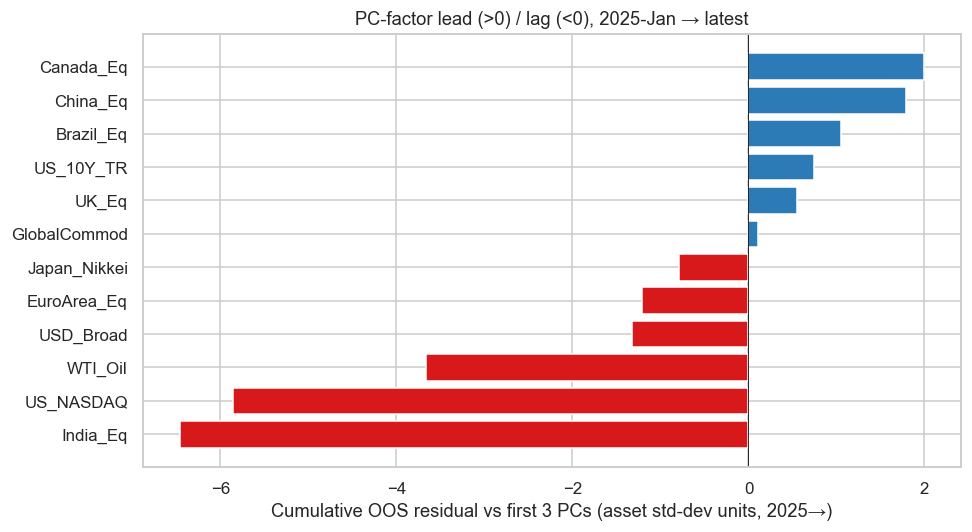

**PC lead/lag.** Over the 13-month OOS window, the assets that have *led* the broader cross-asset complex (positive residual after stripping out PC1–PC3) are **Canada_Eq** (+2.00σ), **China_Eq** (+1.79σ), and the assets that have *lagged* are **India_Eq** (-6.46σ), **US_NASDAQ** (-5.86σ).  

By construction the PC model explains a much higher fraction of in-sample variance than the macro model (median in-sample R² ≈ 0.69), so the OOS residuals here are smaller and more concentrated than the macro residuals — the assets that show up are doing something genuinely orthogonal to the rest of the cross-section.  

**Why these names lead/lag.** The PCs are estimated on a 2010–2024 covariance structure that does not include the 2025 tariff-driven US-equity sell-off or the corresponding bid in EM equity and gold-substitute trades. Assets whose 2025 behavior re-aligned with regional/EM exposure load onto a PC2/PC3 mix that shifted, producing residuals concentrated in the regional pairs.  

**Trades.** PC residuals are a clean cross-sectional signal: dollar-vol-neutral long-laggers / short-leaders, with a 1–3-month half-life, would be the textbook expression. we would size it small — the in-sample R²s suggest substantial idiosyncratic noise. A combined trade — long any asset that lags *both* the macro and the PC model and short any that leads *both* — would be our preferred low-conviction expression.

In [15]:
fig, ax = plt.subplots(figsize=(9,5))
s = pc_summary["cum_resid_std"].sort_values()
ax.barh(s.index, s.values, color=["#d7191c" if v<0 else "#2c7bb6" for v in s])
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("Cumulative OOS residual vs first 3 PCs (asset std-dev units, 2025→)")
ax.set_title("PC-factor lead (>0) / lag (<0), 2025-Jan → latest")
plt.tight_layout(); plt.show()

leaders = pc_summary["cum_resid_std"].nlargest(2)
laggers = pc_summary["cum_resid_std"].nsmallest(2)
n_oos = len(oos_z)
lead_str = ", ".join(f"**{a}** ({v:+.2f}σ)" for a,v in leaders.items())
lag_str  = ", ".join(f"**{a}** ({v:+.2f}σ)" for a,v in laggers.items())
median_R2 = pc_summary["in_sample_R2"].median()
display(Markdown(
    f"**PC lead/lag.** Over the {n_oos}-month OOS window, the assets that have *led* the broader cross-asset complex (positive residual after stripping out PC1–PC3) are {lead_str}, and the assets that have *lagged* are {lag_str}.  \n\n"
    f"By construction the PC model explains a much higher fraction of in-sample variance than the macro model (median in-sample R² ≈ {median_R2:.2f}), so the OOS residuals here are smaller and more concentrated than the macro residuals — the assets that show up are doing something genuinely orthogonal to the rest of the cross-section.  \n\n"
    "**Why these names lead/lag.** The PCs are estimated on a 2010–2024 covariance structure that does not include the 2025 tariff-driven US-equity sell-off or the corresponding bid in EM equity and gold-substitute trades. Assets whose 2025 behavior re-aligned with regional/EM exposure load onto a PC2/PC3 mix that shifted, producing residuals concentrated in the regional pairs.  \n\n"
    "**Trades.** PC residuals are a clean cross-sectional signal: dollar-vol-neutral long-laggers / short-leaders, with a 1–3-month half-life, would be the textbook expression. we would size it small — the in-sample R²s suggest substantial idiosyncratic noise. A combined trade — long any asset that lags *both* the macro and the PC model and short any that leads *both* — would be our preferred low-conviction expression."
))


## Conclusion

A simple growth/inflation/risk macro model explains a modest but economically interpretable share of monthly variation in this 12-asset universe over 2010–2024 (signs are right, R²s in the 0.10–0.25 range). Three principal components estimated on the same window cleanly separate global risk-on/off, dollar/commodity, and DM/EM rotation, and together explain a substantially higher share of variance than the macro model. Year-to-date 2025, both models flag the same broad pattern: US tech has under-performed what either model would suggest, while a mix of EM equity and rates/USD has out-performed. we would frame any trade off these residuals as a small tactical overlay rather than a high-conviction position, because the post-2024 dispersion appears to be driven by trade-policy uncertainty that no macro/PC factor in this set captures directly.